In [8]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Load the data
base_coords = pd.read_csv('coords_base.csv')
base_coords = np.stack([base_coords['x'], base_coords['y'], base_coords['z']], axis=-1)
rho = np.load('rho.npz', allow_pickle=True)
theta = np.load('theta.npz', allow_pickle=True)
phi = np.load('phi.npz', allow_pickle=True)


In [10]:
rho['states'].shape

(8, 32)

In [14]:
# get amplitude
def int2binstr(x, n):
    return format(x, '0' + str(n) + 'b')

def binstr2int(x):
    return int(x, 2)

x = list(range(0, 16))
x_str = ['|'+int2binstr(i, 4)+'>' for i in x]

def run(name, data):
    df = {'x': [], 'x_label': []}
    for i in range(8):
        df['amplitude0_'+str(i)] = []
        df['amplitude1_'+str(i)] = []
        
    for i in range(9):
        k=i*2
        df['x'].append(i)
        df['x_label'].append(x_str[i])
        for j in range(8):
            df[f'amplitude0_{j}'].append(data[j, k].item())
            df[f'amplitude1_{j}'].append(data[j, k+1].item())
    df = pd.DataFrame(df)
    df.to_csv(name+'.csv', index=False)
    
run('rho', rho['states'])
run('theta', theta['states'])
run('phi', phi['states'])

In [18]:
def scale_array(arr):
    target_min_neg = -2
    target_max_neg = -1
    target_min_pos = 1
    target_max_pos = 2
    
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            row = arr[i, :]
            if arr[i, j] < 0:
                min_neg = row[row < 0].min()
                max_neg = row[row < 0].max()
                arr[i, j] = (arr[i, j] - min_neg) * (target_max_neg - target_min_neg) / (max_neg - min_neg) + target_min_neg
                if np.isnan(arr[i,j]):
                    arr[i,j] = target_min_neg
            else:
                min_pos = row[row > 0].min()
                max_pos = row[row > 0].max()
                arr[i, j] = (arr[i, j] - min_pos) * (target_max_pos - target_min_pos) / (max_pos - min_pos) + target_min_pos
                if np.isnan(arr[i,j]):
                    arr[i,j] = target_min_pos
    return arr

prob_coords_x = rho['direct'] * np.cos(theta['direct']) * np.sin(phi['direct'])
prob_coords_y = rho['direct'] * np.sin(theta['direct']) * np.sin(phi['direct'])
prob_coords_z = rho['direct'] * np.cos(phi['direct'])
prob_coords = np.stack([prob_coords_x, prob_coords_y, prob_coords_z], axis=-1)

prob_coords = prob_coords / np.linalg.norm(prob_coords, axis=-1)[:, :, None]
print(prob_coords.shape)

def sum_amplitude(arr):
    res = np.zeros((8, 9))
    for i in range(8):
        for j in range(9):
            k = j * 2
            res[i, j] = arr[i, k] + arr[i, k+1]
    return res
            
strength = sum_amplitude(rho['states']) + sum_amplitude(theta['states']) + sum_amplitude(phi['states'])
print(strength.max(), strength.min(), strength.mean())
print(strength.shape)
strength = scale_array(strength)
print(strength.max(), strength.min(), strength.mean())
print(strength[strength<0].max(), strength[strength<0].min(), strength[strength<0].mean())
print(strength[strength>0].max(), strength[strength>0].min(), strength[strength>0].mean())
prob_coords = prob_coords * strength[:, :, None]
print(prob_coords.shape)
# for i in range(8):
#     prob_coords[i, :, :] += base_coords[i, :]
# print(prob_coords)
np.save('prob_coords.npy', prob_coords)

(8, 9, 3)
3.6771886502889304 -0.18543224432942854 0.34777280533946164
(8, 9)
2.0 -2.0 0.364297706380541
-1.0 -2.0 -1.1646060225191954
2.0 1.0 1.1775443706889115
(8, 9, 3)


In [19]:
import numpy as np
from scipy.io import savemat
print(prob_coords.shape, base_coords.shape)
savemat('coords.mat', {'prob_coords': prob_coords, 'base_coords': base_coords})

(8, 9, 3) (9, 3)


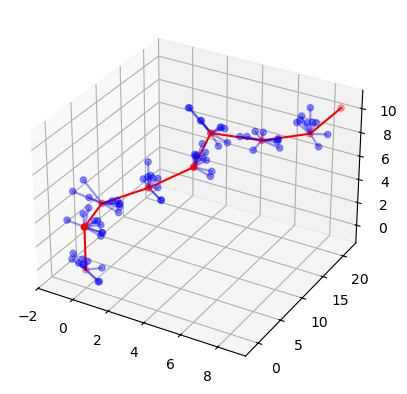

In [20]:
# draw 3d sphere figure
fig = plt.figure()
for i in range(8):
    prob_coords[i, :, :] += base_coords[i, :]
ax = fig.add_subplot(111, projection='3d')
ax.scatter(base_coords[:, 0], base_coords[:, 1], base_coords[:, 2], c='r', marker='o')
ax.plot(base_coords[:, 0], base_coords[:, 1], base_coords[:, 2], c='r')

ax.scatter(prob_coords[:, :, 0], prob_coords[:, :, 1], prob_coords[:, :, 2], c='b', marker='o', alpha=0.4)
for i in range(8):
    for j in range(9):
        ax.plot([base_coords[i, 0], prob_coords[i, j, 0]], 
                [base_coords[i, 1], prob_coords[i, j, 1]],
                [base_coords[i, 2], prob_coords[i, j, 2]], c='b', alpha=0.4)
# print(prob_coords)


In [7]:
rho['states'].shape

(8, 9)